# Smoking & Birth Weight Analysis
Investigating the relationship between maternal smoking and infant birth weight using OLS regression.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.iolib.summary2 import summary_col

# scipy.stats gives us statistical tests like the t-test
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_palette("husl")
sns.set_style("ticks")
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'

## Helper Functions

In [2]:
def fit_and_plot(formula, data, model_name="Model", x_var=None):
    model = smf.ols(formula=formula, data=data).fit()  # fit OLS
    print(model.summary())                              # full statsmodels output

    # infer x_var from the formula if not supplied
    if x_var is None:
        x_var = formula.split('~')[1].strip().split('+')[0].strip()

    y_var     = formula.split('~')[0].strip()   # outcome variable name
    residuals = model.resid                      # actual minus fitted

    # CRITICAL: use only rows the model fitted on (drops NaN rows automatically)
    model_data = data.loc[model.fittedvalues.index]

    is_cat = model_data[x_var].dtype == object or str(model_data[x_var].dtype) == 'category'

    fig = plt.figure(figsize=(15, 10))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.35, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :])   # top panel -- full width
    ax_res  = fig.add_subplot(gs[1, 0])   # bottom-left
    ax_qq   = fig.add_subplot(gs[1, 1])   # bottom-right

    # --- Panel 1: Actual vs Predicted ---
    if is_cat:
        sns.stripplot(x=model_data[x_var], y=model_data[y_var],
                      alpha=0.3, color='black', s=4, ax=ax_main, label='Actual')
        group_means = model_data.groupby(x_var)[y_var].mean()
        ax_main.hlines(group_means.values,
                       xmin=[i - 0.3 for i in range(len(group_means))],
                       xmax=[i + 0.3 for i in range(len(group_means))],
                       colors='red', linewidth=2, label='Predicted mean')
    else:
        # .values avoids index-mismatch issues with matplotlib
        ax_main.scatter(model_data[x_var].values, model_data[y_var].values,
                        alpha=0.3, color='black', s=15, label='Actual')
        ax_main.scatter(model_data[x_var].values, model.fittedvalues.values,
                        alpha=0.3, color='red', s=15, label='Predicted')

    ax_main.set_title(f'Actual vs Predicted -- x: {x_var}', fontsize=13)
    ax_main.set_xlabel(x_var)
    ax_main.set_ylabel(y_var)
    ax_main.legend()

    # --- Panel 2: Residuals vs Fitted ---
    ax_res.scatter(model.fittedvalues, residuals, alpha=0.3, color='steelblue', s=15)
    ax_res.axhline(0, color='red', linewidth=1, linestyle='--')  # zero reference line
    ax_res.set_title('Residuals vs Fitted', fontsize=11)
    ax_res.set_xlabel('Fitted Values')
    ax_res.set_ylabel('Residuals')

    # --- Panel 3: Q-Q Plot ---
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax_qq.scatter(osm, osr, alpha=0.3, color='steelblue', s=15)
    ax_qq.plot(osm, slope * np.array(osm) + intercept,
               color='red', linewidth=1, linestyle='--')  # theoretical normal line
    ax_qq.set_title('Q-Q Plot of Residuals', fontsize=11)
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')

    plt.suptitle(f'{model_name}  |  R2 = {model.rsquared:.3f}  |  Adj R2 = {model.rsquared_adj:.3f}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    return model  # return so we can extract alpha, beta, etc. afterwards


def two_sample_ttest_summary(a, b, col, label_a, label_b):
    """
    Welch two-sample t-test with R-style output:
    n, mean, std, diff, 95% CI, t, df, p-value with significance stars.
    """
    x, y = a[col].dropna(), b[col].dropna()
    t, p = scipy_stats.ttest_ind(x, y, equal_var=False)
    df_w = (x.var()/len(x) + y.var()/len(y))**2 / (
            (x.var()/len(x))**2/(len(x)-1) + (y.var()/len(y))**2/(len(y)-1))
    diff = x.mean() - y.mean()
    se   = np.sqrt(x.var()/len(x) + y.var()/len(y))
    ci   = scipy_stats.t.interval(0.95, df=df_w, loc=diff, scale=se)

    print(f"--- Welch Two-Sample T-Test: {col} | {label_a} vs {label_b} ---")
    print(f"  n         : {len(x)}  vs  {len(y)}")
    print(f"  mean      : {x.mean():,.4f}  vs  {y.mean():,.4f}")
    print(f"  std       : {x.std(ddof=1):,.4f}  vs  {y.std(ddof=1):,.4f}")
    print(f"  diff      : {diff:,.4f}  ({label_a} minus {label_b})")
    print(f"  95% CI    : [{ci[0]:,.4f}, {ci[1]:,.4f}]")
    print(f"  t         : {t:.4f}")
    print(f"  df        : {df_w:.2f}")
    print(f"  p-value   : {p:.6f}  {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}")

print("✅ Helper functions defined.")

✅ Helper functions defined.


## 1. Load & Inspect Data

In [2]:
smoking_birth_weight = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/data_analytics_executives/main/data/smoking_birth_weight.csv")


print("Shape:", smoking_birth_weight.shape)
print("\nMissing values:")
print(smoking_birth_weight.isnull().sum())
smoking_birth_weight.describe()

Shape: (1000, 12)

Missing values:
father_age        171
mother_age          0
mature              0
weeks               2
premie              2
visits              9
lowbirthweight      0
gender              0
habit               1
whitemom            2
weight_kg           0
gained_kg          27
dtype: int64


,father_age,mother_age,weeks,visits,weight_kg,gained_kg
count,829.000000,1000.000000,998.000000,991.000000,1000.000000,973.000000
mean,30.255730,27.000000,38.334669,12.104945,3.223854,13.784453
std,6.763766,6.213583,2.931553,3.954934,0.685023,6.473317
min,14.000000,13.000000,20.000000,0.000000,0.454000,0.000000
25%,25.000000,22.000000,37.000000,10.000000,2.896520,9.090909
50%,30.000000,27.000000,39.000000,12.000000,3.318740,13.636364
75%,35.000000,32.000000,40.000000,15.000000,3.659240,17.272727
max,55.000000,50.000000,45.000000,30.000000,5.334500,38.636364


## 2. Smoking Habit Counts & Proportions

In [4]:
print("Counts:")
display(smoking_birth_weight['habit'].value_counts().to_frame())

print("\nProportions:")
display(smoking_birth_weight['habit'].value_counts(normalize=True).to_frame().round(3))

Counts:


,count
habit,
nonsmoker,873
smoker,126



Proportions:


,proportion
habit,
nonsmoker,0.874
smoker,0.126


## 3. Birth Weight by Smoking Habit

In [5]:
display(
    smoking_birth_weight.groupby('habit')['weight_kg']
    .describe().round(3)
)

,count,mean,std,min,25%,50%,75%,max
habit,,,,,,,,
nonsmoker,873.0,3.243,0.689,0.454,2.924,3.319,3.659,5.334
smoker,126.0,3.100,0.629,0.767,2.759,3.205,3.512,4.172


## 4. Welch Two-Sample T-Test
Using the `two_sample_ttest_summary` helper.

In [6]:
two_sample_ttest_summary(
    smoking_birth_weight.query("habit == 'smoker'").to_frame() if isinstance(smoking_birth_weight.query("habit == 'smoker'"), pd.Series)
    else smoking_birth_weight.query("habit == 'smoker'"),
    smoking_birth_weight.query("habit == 'nonsmoker'"),
    col='weight_kg',
    label_a='Smoker',
    label_b='Non-smoker'
)

--- Welch Two-Sample T-Test: weight_kg | Smoker vs Non-smoker ---
  n         : 126  vs  873
  mean      : 3.1002  vs  3.2435
  std       : 0.6293  vs  0.6895
  diff      : -0.1433  (Smoker minus Non-smoker)
  95% CI    : [-0.2631, -0.0234]
  t         : -2.3590
  df        : 171.32
  p-value   : 0.019451  *


## 5. Model 1 — Intercept Only
`weight_kg ~ 1`

In [8]:
model1 = smf.ols('weight_kg ~ 1', data=smoking_birth_weight).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              weight_kg   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 20 Mar 2026   Prob (F-statistic):                nan
Time:                        20:56:08   Log-Likelihood:                -1040.1
No. Observations:                1000   AIC:                             2082.
Df Residuals:                     999   BIC:                             2087.
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.2239      0.022    148.823      0.0

## 6. Model 2 — Habit Only
`weight_kg ~ habit`

                            OLS Regression Results                            
Dep. Variable:              weight_kg   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     4.855
Date:                Fri, 20 Mar 2026   Prob (F-statistic):             0.0278
Time:                        20:57:03   Log-Likelihood:                -1034.5
No. Observations:                 999   AIC:                             2073.
Df Residuals:                     997   BIC:                             2083.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           3.2435      0.023    1

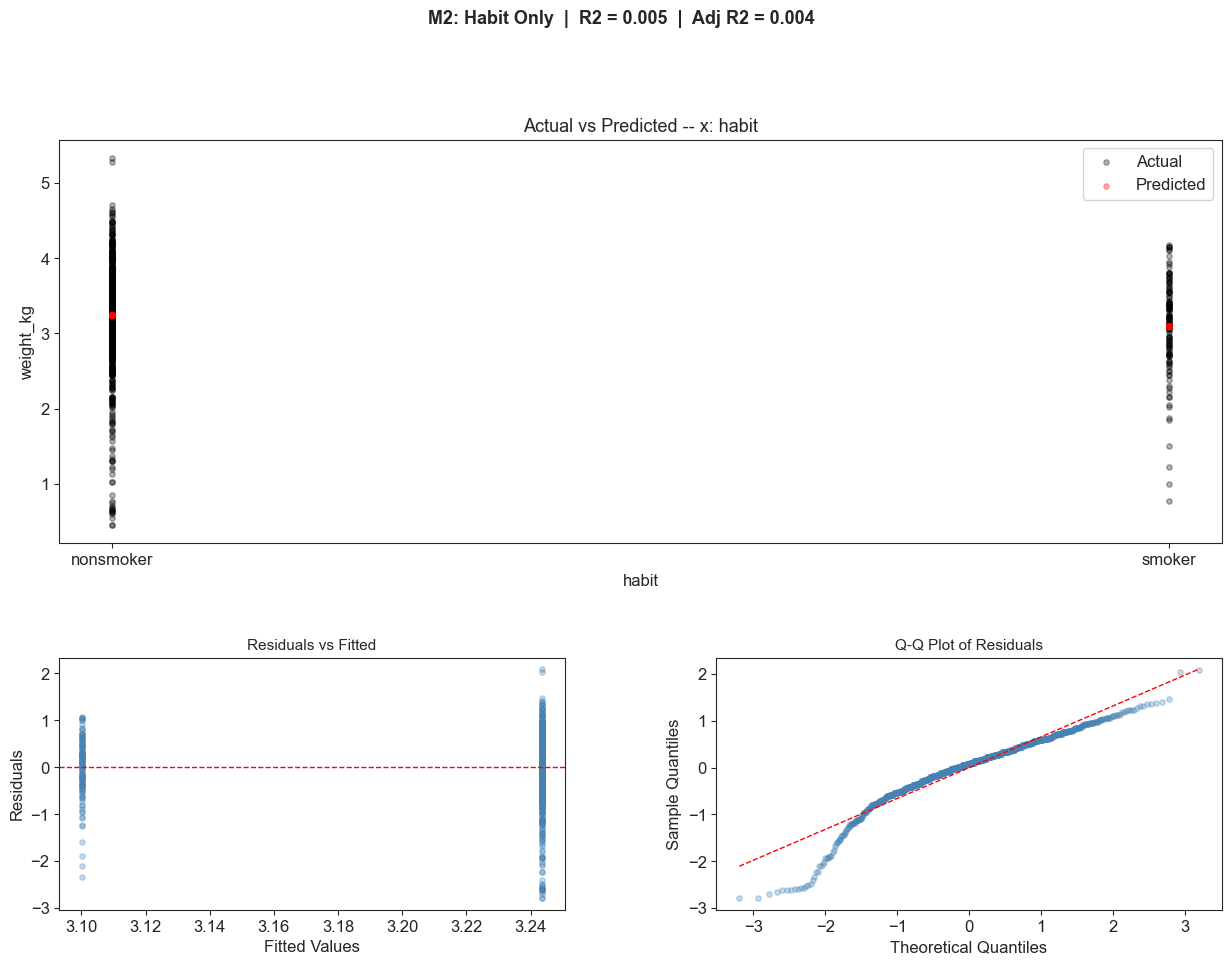

In [11]:
model2 = fit_and_plot(
    formula='weight_kg ~ habit',
    data=smoking_birth_weight,
    model_name='M2: Habit Only',
    x_var='habit'
)

## 7. Model 3 — Weeks + Habit
`weight_kg ~ weeks + habit`

                            OLS Regression Results                            
Dep. Variable:              weight_kg   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     415.8
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          5.47e-132
Time:                        20:57:13   Log-Likelihood:                -733.25
No. Observations:                 998   AIC:                             1472.
Df Residuals:                     995   BIC:                             1487.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -2.7568      0.210    -

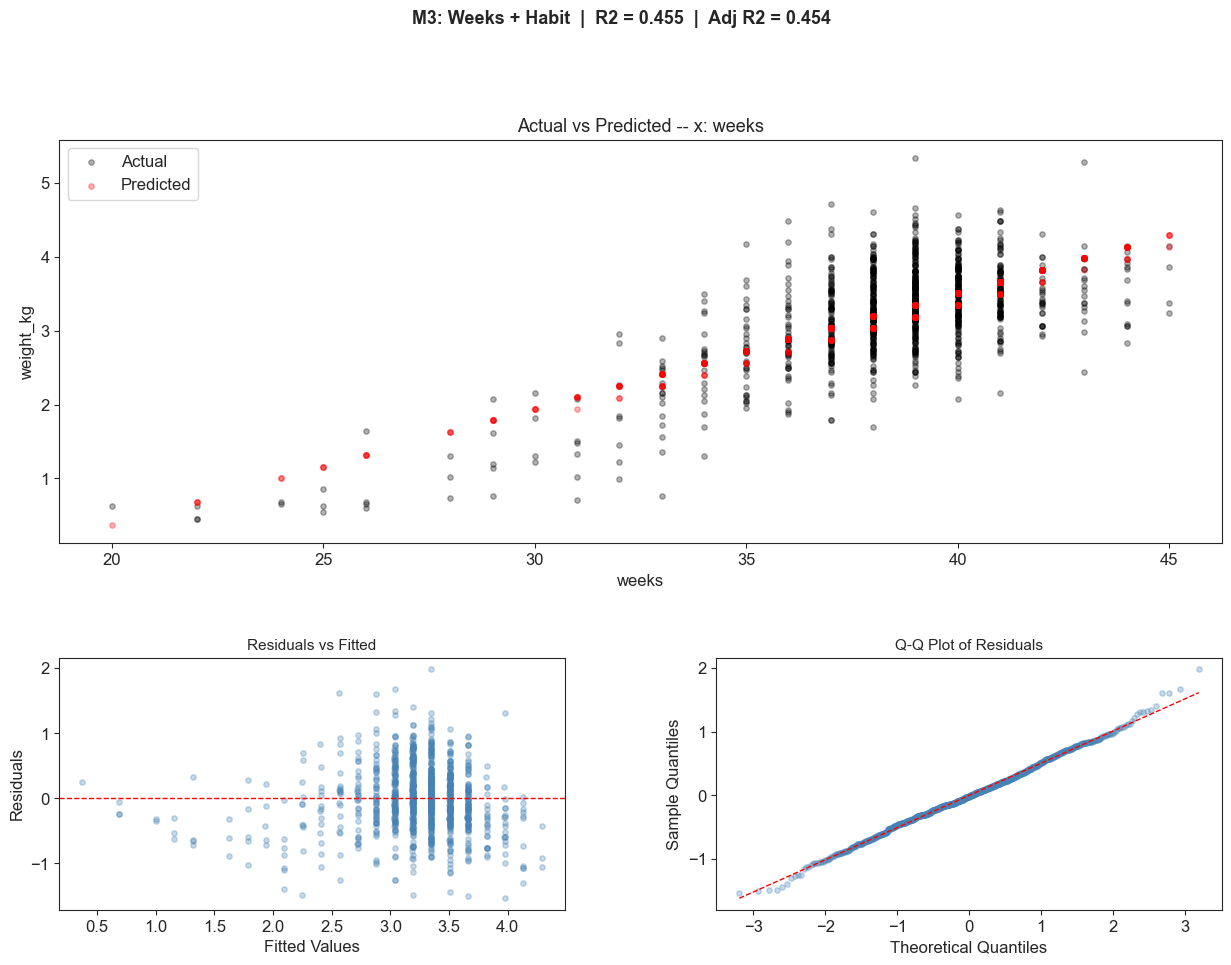

In [12]:
model3 = fit_and_plot(
    formula='weight_kg ~ weeks + habit',
    data=smoking_birth_weight,
    model_name='M3: Weeks + Habit',
    x_var='weeks'
)

## 8. Model 4 — Weeks + Habit + Controls
`weight_kg ~ weeks + habit + gender + whitemom + gained_kg`

                            OLS Regression Results                            
Dep. Variable:              weight_kg   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     178.2
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          2.54e-134
Time:                        20:57:28   Log-Likelihood:                -679.33
No. Observations:                 970   AIC:                             1371.
Df Residuals:                     964   BIC:                             1400.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.8159      0.20

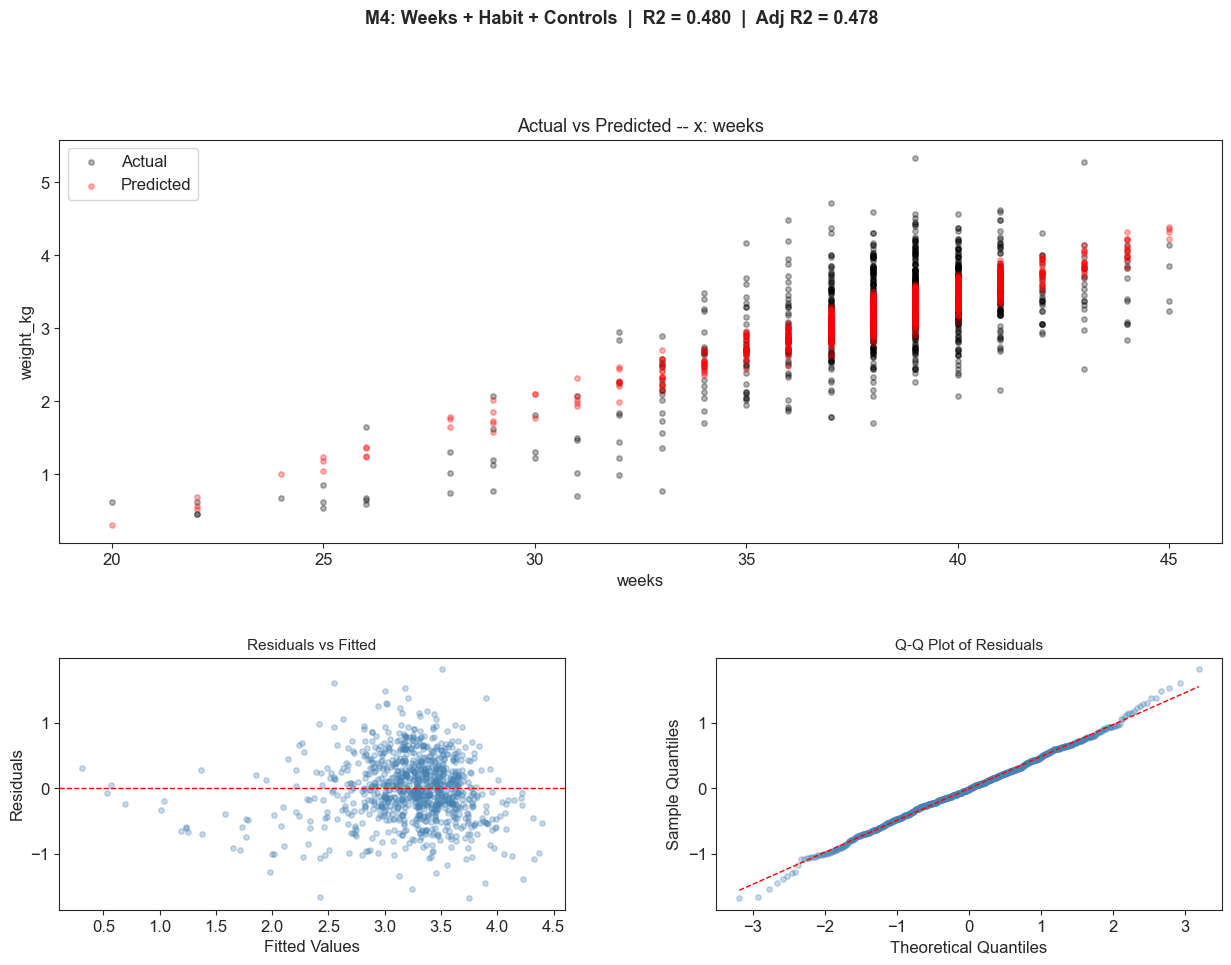

In [13]:
model4 = fit_and_plot(
    formula='weight_kg ~ weeks + habit + gender + whitemom + gained_kg',
    data=smoking_birth_weight,
    model_name='M4: Weeks + Habit + Controls',
    x_var='weeks'
)

## 9. Model 5 — All Variables

                            OLS Regression Results                            
Dep. Variable:              weight_kg   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     109.2
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          3.74e-150
Time:                        20:58:27   Log-Likelihood:                -424.86
No. Observations:                 800   AIC:                             873.7
Df Residuals:                     788   BIC:                             929.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

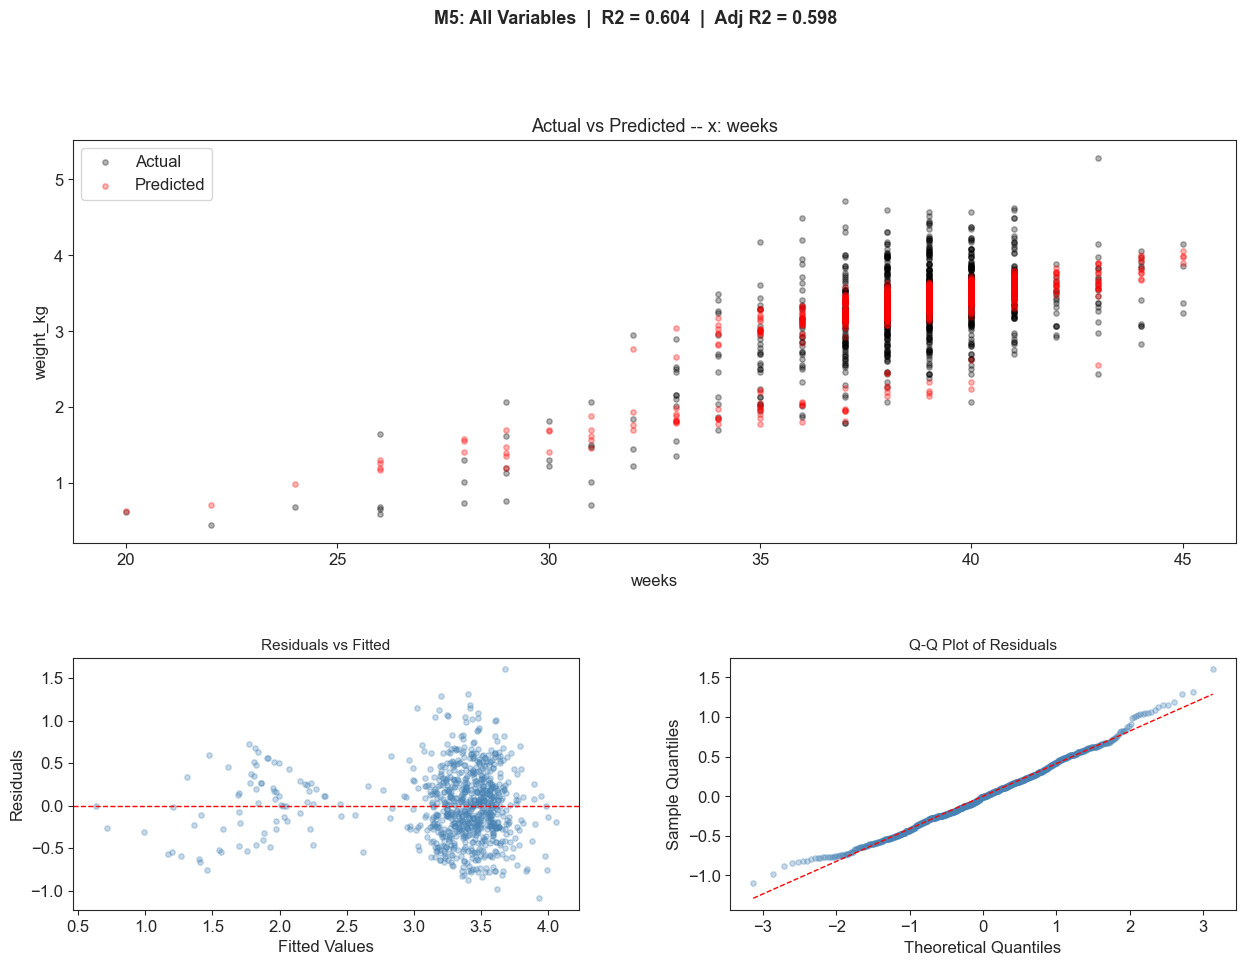

In [15]:
model5 = fit_and_plot(
    formula='weight_kg ~ weeks + habit + whitemom + gender + gained_kg + father_age + mother_age + mature + premie + visits + lowbirthweight',
    data=smoking_birth_weight,
    model_name='M5: All Variables',
    x_var='weeks'
)

## 10. Model Comparison

In [16]:
models = {
    'M1: ~1':                    model1,
    'M2: ~habit':                model2,
    'M3: ~weeks+habit':          model3,
    'M4: ~weeks+habit+controls': model4,
    'M5: ~all vars':             model5,
}

comparison = pd.DataFrame({
    name: {
        'N':           int(m.nobs),
        'R²':          round(m.rsquared, 4),
        'Adj. R²':     round(m.rsquared_adj, 4),
        'Residual SE': round(np.sqrt(m.mse_resid), 3),
        'AIC':         round(m.aic, 1),
    }
    for name, m in models.items()
})

display(comparison)

,M1: ~1,M2: ~habit,M3: ~weeks+habit,M4: ~weeks+habit+controls,M5: ~all vars
N,1000.000,999.0000,998.0000,970.0000,800.0000
R²,-0.000,0.0048,0.4553,0.4803,0.6038
Adj. R²,-0.000,0.0038,0.4542,0.4776,0.5983
Residual SE,0.685,0.6820,0.5050,0.4890,0.4150
AIC,2082.300,2073.0000,1472.5000,1370.7000,873.7000


## 11. Full Coefficient Table

In [17]:
summary = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,
    float_format='%0.3f',
    model_names=['M1', 'M2', 'M3', 'M4', 'M5'],
    info_dict={'Residual SE': lambda x: f"{x.scale ** 0.5:.3f}"}
)
print(summary)


                             M1       M2        M3        M4        M5   
-------------------------------------------------------------------------
Intercept                 3.224*** 3.243*** -2.757*** -2.816*** -1.201***
                          (0.022)  (0.023)  (0.210)   (0.209)   (0.336)  
habit[T.smoker]                    -0.143** -0.163*** -0.197*** -0.098** 
                                   (0.065)  (0.048)   (0.047)   (0.048)  
weeks                                       0.157***  0.150***  0.078*** 
                                            (0.005)   (0.005)   (0.008)  
gender[T.male]                                        0.174***  0.173*** 
                                                      (0.031)   (0.030)  
whitemom[T.white]                                     0.139***  0.122*** 
                                                      (0.035)   (0.036)  
gained_kg                                             0.009***  0.007*** 
                                     